In [4]:
import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
#from tqdm import tqdm
import pandas as pd
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import LSTM, Embedding, TimeDistributed, Dense, RepeatVector, Activation, Flatten
from keras.optimizers import Adam, RMSprop
from keras.layers import Bidirectional
from keras.applications.inception_v3 import InceptionV3
from keras.preprocessing import image
import nltk

## Data Preprocessing

In [5]:
from tqdm import tqdm

In [6]:
token = 'Flickr8k.token.txt'


In [7]:
captions = open(token, 'r').read().strip().split('\n')
captions

['1000268201_693b08cb0e.jpg#0\tA child in a pink dress is climbing up a set of stairs in an entry way .',
 '1000268201_693b08cb0e.jpg#1\tA girl going into a wooden building .',
 '1000268201_693b08cb0e.jpg#2\tA little girl climbing into a wooden playhouse .',
 '1000268201_693b08cb0e.jpg#3\tA little girl climbing the stairs to her playhouse .',
 '1000268201_693b08cb0e.jpg#4\tA little girl in a pink dress going into a wooden cabin .',
 '1001773457_577c3a7d70.jpg#0\tA black dog and a spotted dog are fighting',
 '1001773457_577c3a7d70.jpg#1\tA black dog and a tri-colored dog playing with each other on the road .',
 '1001773457_577c3a7d70.jpg#2\tA black dog and a white dog with brown spots are staring at each other in the street .',
 '1001773457_577c3a7d70.jpg#3\tTwo dogs of different breeds looking at each other on the road .',
 '1001773457_577c3a7d70.jpg#4\tTwo dogs on pavement moving toward each other .',
 '1002674143_1b742ab4b8.jpg#0\tA little girl covered in paint sits in front of a pai

In [8]:
for i, row in enumerate(captions):
    row = row.split('\t')
    row[0] = row[0][:len(row[0])-2]
print(row[0])


997722733_0cb5439472.jpg


In [9]:

d = {}
for i, row in enumerate(captions):
    row = row.split('\t')
    row[0] = row[0][:len(row[0])-2]
    if row[0] in d:
        d[row[0]].append(row[1])
    else:
        d[row[0]] = [row[1]]
d        

{'1000268201_693b08cb0e.jpg': ['A child in a pink dress is climbing up a set of stairs in an entry way .',
  'A girl going into a wooden building .',
  'A little girl climbing into a wooden playhouse .',
  'A little girl climbing the stairs to her playhouse .',
  'A little girl in a pink dress going into a wooden cabin .'],
 '1001773457_577c3a7d70.jpg': ['A black dog and a spotted dog are fighting',
  'A black dog and a tri-colored dog playing with each other on the road .',
  'A black dog and a white dog with brown spots are staring at each other in the street .',
  'Two dogs of different breeds looking at each other on the road .',
  'Two dogs on pavement moving toward each other .'],
 '1002674143_1b742ab4b8.jpg': ['A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .',
  'A little girl is sitting in front of a large painted rainbow .',
  'A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .',
  'T

In [10]:
d['1002674143_1b742ab4b8.jpg']

['A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .',
 'A little girl is sitting in front of a large painted rainbow .',
 'A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .',
 'There is a girl with pigtails sitting in front of a rainbow painting .',
 'Young girl with pigtails painting outside in the grass .']

In [11]:
images = 'Images/'


In [12]:
# Contains all the images
img = glob.glob(images+'*.jpg')

In [13]:
img[:5]

['Images\\1000268201_693b08cb0e.jpg',
 'Images\\1001773457_577c3a7d70.jpg',
 'Images\\1002674143_1b742ab4b8.jpg',
 'Images\\1003163366_44323f5815.jpg',
 'Images\\1007129816_e794419615.jpg']

In [14]:
from IPython.display import Image

In [15]:
train_images_file = 'Flickr_8k.trainImages.txt'


In [16]:
train_images = set(open(train_images_file, 'r').read().strip().split('\n'))
print(train_images)                  

{'3562001359_65c63aeda3.jpg', '162743064_bb242faa31.jpg', '3216085740_699c2ce1ae.jpg', '2348491126_30db0d46ef.jpg', '3463523977_f2ed231585.jpg', '498957941_f0eda42787.jpg', '3639684919_cb6fbf5638.jpg', '3374054694_fa56f29267.jpg', '3124964754_2e8a98fb09.jpg', '2757779501_c41c86a595.jpg', '2916009941_34a0013803.jpg', '3461677493_5bfb73038e.jpg', '345284642_77dded0907.jpg', '3399843227_3b9d2a8dbf.jpg', '2655183854_5852790214.jpg', '2747436384_9470c56cb9.jpg', '3561130207_d1ed166daa.jpg', '3104182973_5bb1c31275.jpg', '1312954382_cf6d70d63a.jpg', '3640743904_d14eea0a0b.jpg', '3533922605_a2b1e276f6.jpg', '294549892_babb130543.jpg', '3533470072_87a5b595ba.jpg', '2071309418_1d7580b0f0.jpg', '3358380484_b99b48f0c9.jpg', '2519812011_f85c3b5cb5.jpg', '537225246_dd0e2158a7.jpg', '521186251_e97d1f50f8.jpg', '3171250845_5ae0d2a8bc.jpg', '3360823754_90967276ec.jpg', '1352398363_9cc8ffcce9.jpg', '2387197355_237f6f41ee.jpg', '1810651611_35aae644fb.jpg', '3476381830_3751dd9339.jpg', '693450725_8ad72389

In [17]:
def split_data(l):
    temp = []
    for i in img:
        if i[len(images):] in l:
            temp.append(i)
    return temp

In [18]:
# Getting the training images from all the images
train_img = split_data(train_images)
len(train_img)


6000

In [19]:
val_images_file = 'Flickr_8k.devImages.txt'
val_images = set(open(val_images_file, 'r').read().strip().split('\n'))


In [20]:
# Getting the validation images from all the images
val_img = split_data(val_images)
len(val_img)

1000

In [21]:
test_images_file = 'Flickr_8k.testImages.txt'
test_images = set(open(test_images_file, 'r').read().strip().split('\n'))

In [22]:
# Getting the test images from all the images
test_img = split_data(test_images)
len(test_images)

1000

In [23]:
def preprocess_input(x):
    x /= 255.
    x -= 0.5
    x *= 2.
    return x

In [24]:
def preprocess(image_path):
    img = image.load_img(image_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    x = preprocess_input(x)
    return x

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


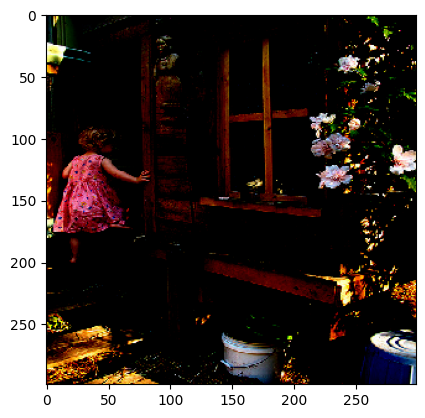

In [25]:
plt.imshow(np.squeeze(preprocess(train_img[0])))

In [26]:
(preprocess(train_img[0])).shape

(1, 299, 299, 3)

In [27]:
np.squeeze(preprocess(train_img[0]))

array([[[-0.54509807, -0.56078434, -0.3960784 ],
        [-0.09803921,  0.02745104,  0.0196079 ],
        [-0.06666666,  0.05098045,  0.09019613],
        ...,
        [-0.9607843 , -0.9607843 , -0.9764706 ],
        [-0.96862745, -0.96862745, -0.9843137 ],
        [-0.9529412 , -0.9529412 , -0.96862745]],

       [[-0.5921569 , -0.6       , -0.4588235 ],
        [-0.09803921,  0.0196079 , -0.03529412],
        [-0.05882353,  0.07450986,  0.13725495],
        ...,
        [-0.96862745, -0.9764706 , -1.        ],
        [-0.94509804, -0.92941177, -0.9529412 ],
        [-0.9843137 , -0.96862745, -0.9764706 ]],

       [[-0.6156863 , -0.6392157 , -0.47450978],
        [-0.09019607,  0.02745104,  0.00392163],
        [-0.0745098 ,  0.05098045,  0.15294123],
        ...,
        [-0.9137255 , -0.9137255 , -0.92941177],
        [-0.8901961 , -0.7647059 , -0.9764706 ],
        [-0.78039217, -0.6       , -0.9607843 ]],

       ...,

       [[ 0.32549024, -0.5529412 , -0.94509804],
        [ 0

In [28]:
dpk = np.squeeze(preprocess(train_img[0])).shape
dpk

(299, 299, 3)

In [29]:
model = InceptionV3(weights='imagenet')


![title](./pics/image03.png)

In [30]:
from keras.models import Model

new_input = model.input
hidden_layer = model.layers[-2].output

model_new = Model(new_input, hidden_layer)

In [31]:
tryi = model_new.predict(preprocess(train_img[10]))


1/1 [==============================] - 3s 3s/step


In [32]:
tryi.shape

(1, 2048)

In [33]:
def encode(image):
    image = preprocess(image)
    temp_enc = model_new.predict(image)
    temp_enc = np.reshape(temp_enc, temp_enc.shape[1])
    return temp_enc


In [34]:

encoding_train = {}
for img in tqdm(train_img):
    encoding_train[img[len(images):]] = encode(img)

  0%|          | 0/6000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 201ms/step


  0%|          | 1/6000 [00:00<27:32,  3.63it/s]

1/1 [==============================] - 0s 204ms/step


  0%|          | 2/6000 [00:00<29:54,  3.34it/s]

...

100%|█████████▉| 5998/6000 [29:46<00:00,  3.74it/s]

1/1 [==============================] - 0s 144ms/step


100%|█████████▉| 5999/6000 [29:47<00:00,  3.77it/s]

1/1 [==============================] - 0s 147ms/step


100%|██████████| 6000/6000 [29:47<00:00,  3.36it/s]


NOTE: uncomment the code above and below to encode for train images

In [35]:
encoding_train['3556792157_d09d42bef7.jpg'].shape

(2048,)

Here we have used the tqdm package as we explained above. it is really helpful as you can be exactly how much time it will take your loop to work and also shows progress bar!!

In [36]:
encoding_test = {}
for img in tqdm(test_img):
    encoding_test[img[len(images):]] = encode(img)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 140ms/step


  0%|          | 1/1000 [00:00<06:06,  2.72it/s]

1/1 [==============================] - 0s 114ms/step


  0%|          | 2/1000 [00:00<04:37,  3.59it/s]

...

100%|█████████▉| 998/1000 [04:18<00:00,  3.38it/s]

1/1 [==============================] - 0s 130ms/step


100%|█████████▉| 999/1000 [04:18<00:00,  3.54it/s]

1/1 [==============================] - 0s 134ms/step


100%|██████████| 1000/1000 [04:18<00:00,  3.86it/s]


In [37]:
encoding_test[test_img[0][len(images):]].shape


(2048,)

In [38]:
train_d = {}
for i in train_img:
    if i[len(images):] in d:
        train_d[i] = d[i[len(images):]]

        

test_d = {}
for i in test_img:
    if i[len(images):] in d:
        test_d[i] = d[i[len(images):]]

In [39]:

caps = []
for key, val in train_d.items():
    for i in val:
        caps.append('<start> ' + i + ' <end>')
        
len(caps)

30000

In [40]:

words = [i.split() for i in caps]

In [41]:
words = [i.split() for i in caps]
unique = []
for i in words:
    unique.extend(i)

In [44]:

unique = list(set(unique))

In [45]:

thefile = open('Inception_vocab.txt', 'w')
for item in unique:
  thefile.write(str(item) + "\n")
thefile.close() 

In [46]:
def file_len(fname):
    with open(fname) as f:
        for i, l in enumerate(f):
            pass
    return i + 1

In [47]:
file_len('Inception_vocab.txt')

8256

In [48]:


word2idx = {val:index for index, val in enumerate(unique)}

In [49]:
word2idx['<start>']


6272

In [50]:
idx2word = {index:val for index, val in enumerate(unique)}

In [51]:
idx2word[5553]

'diver'

In [52]:

max_len = 0
for c in caps:
    c = c.split()
    if len(c) > max_len:
        max_len = len(c)
max_len

40

In [53]:

vocab_size = len(unique)
vocab_size

8256

In [54]:
f = open('flickr8k_training_dataset.txt', 'w')
f.write("image_id\tcaptions\n")

18

In [55]:
f1 = open('flickr8k_test_dataset.txt', 'w')
f1.write("image_id\tcaptions\n")

for key, val in test_d.items():
    for i in val:
        f1.write(key[len(images):] + "\t" + "<start> " + i +" <end>" + "\n")

f1.close()

df_test=pd.read_csv('flickr8k_test_dataset.txt', delimiter='\t')

In [56]:

for key, val in train_d.items():
    for i in val:
        f.write(key[len(images):] + "\t" + "<start> " + i +" <end>" + "\n")

f.close()

In [57]:
df = pd.read_csv('flickr8k_training_dataset.txt', delimiter='\t')


In [58]:

c = [i for i in df['captions']]
len(c)

30000

In [59]:
imgs = [i for i in df['image_id']]

In [60]:

a = c[10]
a, imgs[10]

('<start> A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl . <end>',
 '1002674143_1b742ab4b8.jpg')

In [61]:

for i in a.split():
    print (i, "->", word2idx[i])

<start> -> 6272
A -> 6416
little -> 2204
girl -> 4817
covered -> 5251
in -> 448
paint -> 1439
sits -> 7439
in -> 448
front -> 8039
of -> 912
a -> 6237
painted -> 2578
rainbow -> 7283
with -> 3046
her -> 4942
hands -> 3541
in -> 448
a -> 6237
bowl -> 5404
. -> 3558
<end> -> 4641


In [62]:
samples_per_epoch = 5
for ca in caps:
    samples_per_epoch += len(ca.split())-1
samples_per_epoch    

383459

In [63]:

def data_generator(batch_size = 32):
        partial_caps = []
        next_words = []
        images = []
        
        df = pd.read_csv('flickr8k_training_dataset.txt', delimiter='\t')
        df = df.sample(frac=1) #frac is used to return fraction of axis items
        iter = df.iterrows()
        c = []
        imgs = []
        for i in range(df.shape[0]):
            x = next(iter)
            c.append(x[1][1])
            imgs.append(x[1][0])


        count = 0
        while True:
            for j, text in enumerate(c):
                current_image = encoding_train[imgs[j]]
                for i in range(len(text.split())-1):
                    count+=1
                    
                    partial = [word2idx[txt] for txt in text.split()[:i+1]]
                    partial_caps.append(partial)
                    
                    # Initializing with zeros to create a one-hot encoding matrix
                    # This is what we have to predict
                    # Hence initializing it with vocab_size length
                    n = np.zeros(vocab_size)
                    # Setting the next word to 1 in the one-hot encoded matrix
                    n[word2idx[text.split()[i+1]]] = 1
                    next_words.append(n)
                    
                    images.append(current_image)

                    if count>=batch_size:
                        next_words = np.asarray(next_words)
                        images = np.asarray(images)
                        partial_caps = sequence.pad_sequences(partial_caps, maxlen=max_len, padding='post')
                        yield [[images, partial_caps], next_words]
                        partial_caps = []
                        next_words = []
                        images = []
                        count = 0

In [64]:
from keras.layers import Concatenate
from keras.layers import Activation, Dense
from keras.layers import Input, Dropout
from keras.layers import concatenate
from keras.layers import Add
from keras.utils import plot_model


In [ ]:

def predict_captions(image):
    start_word = ["<start>"]
    while True:
        par_caps = [word2idx[i] for i in start_word]
        par_caps = sequence.pad_sequences([par_caps], maxlen=max_len, padding='post')
        e = encoding_test[image[len(images):]]
        preds = ultimate_model_2.predict([np.array([e]), np.array(par_caps)])
        word_pred = idx2word[np.argmax(preds[0])]
        start_word.append(word_pred)
        
        if word_pred == "<end>" or len(start_word) > max_len:
            break
            
    return ' '.join(start_word[1:-1])

In [68]:
from keras.utils import to_categorical
from keras.utils import plot_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from keras.models import Model
from keras.layers import Input
from keras.layers import Bidirectional , TimeDistributed
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Embedding
from keras.layers import Dropout
from keras.layers import add

# define the captioning model
def define_model_2(vocab_size, max_len,embedding_size = 300):
    # feature extractor model
    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.2)(inputs1)
    fe2 = Dense(embedding_size, activation='relu')(fe1)
    # sequence model
    inputs2 = Input(shape=(max_len,))
    se1 = Embedding(vocab_size, embedding_size, mask_zero=True)(inputs2)
    se2 = Dropout(0.2)(se1)
    se3 = Bidirectional(LSTM(256,return_sequences=True))(se2)
    se4 = TimeDistributed(Dense(300))(se3)
    # decoder model
    main1 = Add()([fe2, se4])
    se4 = Dropout(0.2)(main1)
    BLSTM1 = Bidirectional(LSTM(256, return_sequences=True))(se4)
    print(BLSTM1.shape)
    BLSTM2 = Bidirectional(LSTM(256))(BLSTM1)
    decoder2 = Dense(256, activation='relu')(BLSTM2)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)
    # tie it together [image, seq] [word]
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy',  optimizer='RMSprop')
    # summarize model
    model.summary()
    
    return model
    

In [69]:
trial_model = define_model_2(8256,40)

(None, 40, 512)
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 40)]                 0         []                            
                                                                                                  
 embedding_1 (Embedding)     (None, 40, 300)              2476800   ['input_5[0][0]']             
                                                                                                  
 input_4 (InputLayer)        [(None, 2048)]               0         []                            
                                                                                                  
 dropout_4 (Dropout)         (None, 40, 300)              0         ['embedding_1[0][0]']         
                                                                            

In [71]:


batch_size = 10
trial_model.fit_generator(data_generator(batch_size), steps_per_epoch=2000,epochs=10,verbose=1)

C:\Users\vmani\AppData\Local\Temp\ipykernel_3584\42156499.py:7: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  trial_model.fit_generator(data_generator(batch_size), steps_per_epoch=2000,epochs=10,verbose=1)


Epoch 1/10
2000/2000 [==============================] - 1721s 860ms/step - loss: 5.3942
Epoch 2/10
2000/2000 [==============================] - 1701s 851ms/step - loss: 5.3561
Epoch 3/10
2000/2000 [==============================] - 1719s 859ms/step - loss: 5.3523
Epoch 4/10
2000/2000 [==============================] - 1728s 864ms/step - loss: 5.4058
Epoch 5/10
2000/2000 [==============================] - 1747s 874ms/step - loss: 5.2505
Epoch 6/10
2000/2000 [==============================] - 1564s 782ms/step - loss: 4.9515
Epoch 7/10
2000/2000 [==============================] - 1730s 865ms/step - loss: 4.7039
Epoch 8/10
2000/2000 [==============================] - 1653s 827ms/step - loss: 4.6363
Epoch 9/10
2000/2000 [==============================] - 1763s 881ms/step - loss: 4.6378
Epoch 10/10
2000/2000 [==============================] - 1746s 873ms/step - loss: 4.6381


In [72]:
trial_model.save_weights('GPU_blstm_model1_exp1_loss.h5')
from keras.models import load_model
trial_model_json_model = trial_model.to_json()

trial_model.save('GPU_blstm_trial_model.h5')



z:\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [73]:
from keras.models import load_model
t_model = load_model('GPU_blstm_trial_model.h5')

In [74]:
def predict_captions_2(image):
    start_word = ["<start>"]
    while True:
        par_caps = [word2idx[i] for i in start_word]
        par_caps = sequence.pad_sequences([par_caps], maxlen=max_len, padding='post')
        e = encoding_test[image[len(images):]]
        preds = t_model.predict([np.array([e]), np.array(par_caps)])
        word_pred = idx2word[np.argmax(preds[0])]
        start_word.append(word_pred)
        
        if word_pred == "<end>" or len(start_word) > max_len:
            break
            
    return ' '.join(start_word[1:-1])

In [76]:
#Import BLSTM model from saved file
from keras.models import load_model
t_model = load_model('GPU_blstm_trial_model.h5')

In [77]:
#Import tokenizer from nltk
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vmani\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [78]:
#Predict captions for BLSTM
#Returns a dictionary with image and predicted caption
pred_dict = {}
for img in tqdm(test_img):
    pred_sent = predict_captions_2(img)
    pred_dict[img] = word_tokenize(pred_sent)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 73ms/step


  0%|          | 1/1000 [00:22<6:18:22, 22.72s/it]

1/1 [==============================] - 0s 56ms/step


  0%|          | 2/1000 [00:25<3:05:19, 11.14s/it]

...

100%|█████████▉| 998/1000 [31:01<00:03,  1.84s/it]

1/1 [==============================] - 0s 55ms/step


100%|█████████▉| 999/1000 [31:03<00:01,  1.79s/it]

1/1 [==============================] - 0s 54ms/step


100%|██████████| 1000/1000 [31:05<00:00,  1.87s/it]


In [79]:
#Sentence bleu function to calculate bleu score using tokenized sentences
from nltk.translate.bleu_score import sentence_bleu


In [80]:
#Calculate BLEU for BLSTM
#Compares both dictionaries to give an output bleu score for each image
dict_map_2 = {}
for img in tqdm(pred_dict.keys()):
    predicted_sentence = pred_dict[img]
    sent_list = []
    for sent in test_d[img]:
        sent_list.append(word_tokenize(sent))
    #Check bleu
    #score = sentence_bleu(sent_list, predicted_sentence)
    score = sentence_bleu(sent_list, predicted_sentence, weights=(1, 0, 0, 0))
    dict_map_2[img] = score

  0%|          | 0/1000 [00:00<?, ?it/s]z:\Python310\lib\site-packages\nltk\translate\bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
z:\Python310\lib\site-packages\nltk\translate\bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
z:\Python310\lib\site-packages\nltk\translate\bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  wa

In [81]:
#BLEU score is aggregated
blue_val = 0
for it in dict_map_2.values():
    blue_val = blue_val + it

In [ ]:
#Convert to percentage
bleu_val / 1000

0.5764705346734418